# Steam Dataset Exploration

This notebook explores the Steam Games dataset.

The objectives are to:

- understand the dataset structure
- assess data quality
- identify missing values and inconsistencies
- determine which fields are suitable for database integration
- identify any cleaning required before analysis

In [36]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [37]:
with open("../data/raw/games.json", "r", encoding="utf-8") as f:
    steam_data = json.load(f)

KeyboardInterrupt: 

In [ ]:
type(steam_data)

dict

In [ ]:
len(steam_data)

135043

In [ ]:

key = list(steam_data.keys())[0]
key, steam_data[key]

('2539430',
 {'name': 'Black Dragon Mage Playtest',
  'release_date': 'Aug 1, 2023',
  'required_age': 0,
  'price': 0.0,
  'dlc_count': 0,
  'detailed_description': '',
  'about_the_game': '',
  'short_description': '',
  'reviews': '',
  'header_image': 'https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/header.jpg?t=1699268702',
  'website': '',
  'support_url': '',
  'support_email': '',
  'windows': True,
  'mac': False,
  'linux': False,
  'metacritic_score': 0,
  'metacritic_url': '',
  'achievements': 0,
  'recommendations': 0,
  'notes': '',
  'supported_languages': [],
  'full_audio_languages': [],
  'packages': [],
  'developers': [],
  'publishers': [],
  'categories': [],
  'genres': [],
  'screenshots': ['https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/ss_7d9504b958d0b143d053d31cb74b375daba338d6.1920x1080.jpg?t=1699268702',
   'https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/ss_85d2749d23e115b4d

In [ ]:
steam_data[key].keys()

dict_keys(['name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags'])

In [ ]:
steam = pd.DataFrame.from_dict(
    steam_data,
    orient="index"
)

In [ ]:
steam.head()

,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,,,,True,False,False,0,,0,0,,[],[],[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,[],0,,0,0,0 - 0,0,0,0,0,0,0,[]
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,,0,231,,[English],[],[{'title': 'Buy Supipara - Chapter 1 Spring Ha...,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[https://shared.akamai.steamstatic.com/store_i...,[],0,,252,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':..."
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,,0,0,,"[English, French, German, Russian]",[],[{'title': 'Buy Mystery Solitaire The Black Ra...,[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[https://shared.akamai.steamstatic.com/store_i...,[],0,,21,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4..."
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,,,yujingamesc@gmail.com,True,False,False,0,,19,0,The game includes the following elements. 1. G...,[Korean],[Korean],"[{'title': 'Buy 버튜버 파라노이아 - Vtuber Paranoia', ...",[유진게임즈],[유진게임즈],"[Single-player, Steam Achievements, Family Sha...","[Casual, Indie, Simulation]",[https://shared.akamai.steamstatic.com/store_i...,[],0,,0,0,0 - 20000,0,0,0,0,0,1,[]
3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,,0,0,,[English],[English],"[{'title': 'Buy Maze Quest VR', 'description':...",[Reality Expanded LLC],[Reality Expanded LLC],"[Single-player, VR Only, Steam Leaderboards, F...","[Action, Early Access]",[https://shared.akamai.steamstatic.com/store_i...,[],0,,0,0,0 - 20000,0,0,0,0,0,0,[]


In [ ]:
steam.index.name = "appid"

In [ ]:
steam = steam.reset_index()

In [ ]:
steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135043 entries, 0 to 135042
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   appid                     135043 non-null  object 
 1   name                      135043 non-null  object 
 2   release_date              135043 non-null  object 
 3   required_age              135043 non-null  int64  
 4   price                     135043 non-null  float64
 5   dlc_count                 135043 non-null  int64  
 6   detailed_description      135043 non-null  object 
 7   about_the_game            135043 non-null  object 
 8   short_description         135043 non-null  object 
 9   reviews                   135043 non-null  object 
 10  header_image              135043 non-null  object 
 11  website                   135043 non-null  object 
 12  support_url               135043 non-null  object 
 13  support_email             135043 non-null  o

In [ ]:
steam.describe()

,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,positive,negative,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,peak_ccu
count,135043.000000,135043.000000,135043.000000,135043.000000,135043.000000,1.350430e+05,135043.000000,1.350430e+05,1.350430e+05,1.350430e+05,135043.000000,1.350430e+05,135043.000000,1.350430e+05
mean,0.157550,4.922020,0.513214,2.334145,17.612768,8.772545e+02,0.022289,9.489852e+02,1.536921e+02,1.891695e+02,12.758929,1.578881e+02,13.635035,4.956888e+01
std,1.603713,12.617517,13.885419,13.051792,134.968856,2.085049e+04,1.329162,2.676916e+04,5.121521e+03,1.068904e+04,257.873751,1.067456e+04,280.964203,3.553676e+03
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,0.000000,0.590000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
50%,0.000000,2.490000,0.000000,0.000000,2.000000,0.000000e+00,0.000000,3.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
75%,0.000000,5.990000,0.000000,0.000000,19.000000,0.000000e+00,0.000000,2.900000e+01,8.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
max,21.000000,999.990000,3703.000000,97.000000,9821.000000,4.830455e+06,100.000000,7.642084e+06,1.173003e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,1.013936e+06


The numerical summary highlights several characteristics of the Steam dataset:

- Most games have low player engagement metrics, with the median values for reviews, recommendations, playtime and peak CCU close to zero.
- The dataset contains significant outliers, with a small number of highly successful games dominating player activity.
- Price data contains extreme values, requiring validation during cleaning.
- Review counts and playtime metrics are highly right-skewed.
- Several metrics contain zero values, which may represent either low engagement or missing/limited data.

In [ ]:
steam["release_date"].head()

0     Aug 1, 2023
1    Jul 29, 2016
2     May 6, 2019
3    Oct 31, 2024
4    Apr 24, 2025
Name: release_date, dtype: object

In [ ]:
steam["release_date"] = pd.to_datetime(
    steam["release_date"],
    errors="coerce"
)

In [ ]:
steam["release_date"].dt.year.value_counts().sort_index()

release_date
1997        2
1998        1
1999        2
2000        2
2001        4
2002        1
2003        3
2004        6
2005        7
2006       69
2007       90
2008      158
2009      321
2010      255
2011      260
2012      322
2013      468
2014     1524
2015     2517
2016     4143
2017     5927
2018     7461
2019     7245
2020     8808
2021    11071
2022    12288
2023    14603
2024    20041
2025    24976
2026    12468
Name: count, dtype: int64

In [ ]:
steam["estimated_owners"].value_counts().head(20)

estimated_owners
0 - 20000                76857
0 - 0                    32605
20000 - 50000            11400
50000 - 100000            5358
100000 - 200000           3457
200000 - 500000           2857
500000 - 1000000          1155
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

<Axes: >

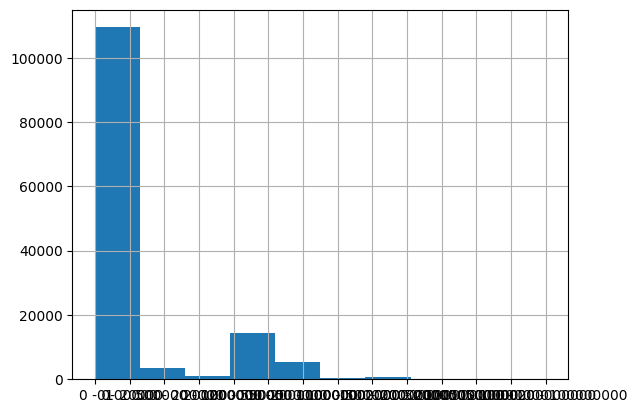

In [38]:
steam["estimated_owners"].hist()

In [ ]:
steam["genres"].value_counts().head(20)

genres
[]                                    8433
[Casual, Indie]                       7563
[Action, Indie]                       6134
[Action, Adventure, Indie]            5527
[Adventure, Indie]                    4724
[Adventure, Casual, Indie]            3933
[Casual]                              3753
[Action, Casual, Indie]               3721
[Indie]                               3394
[Action]                              3231
[Casual, Indie, Strategy]             2596
[Casual, Indie, Simulation]           2580
[Adventure]                           2323
[Action, Adventure, Casual, Indie]    2210
[Action, Adventure]                   1807
[Action, Adventure, Indie, RPG]       1661
[Adventure, Casual]                   1653
[Adventure, Indie, RPG]               1648
[Strategy]                            1498
[Indie, Strategy]                     1393
Name: count, dtype: int64